# Tennessee Eastman Process — Datensynthese

Erzeugt Kampagnen-, Produktions- und Fehlerfalldaten (IDV 29, Kalibrierdrift auf XMEAS(18)) des angepassten Tennessee Eastman-Prozesses und speichert sie als `data_campaign`/`data_production`/`data_error` (plus `data_prerun`) im `data_dir`; *tep_model*, *tep_detection* und *tep_adaptation* laden von dort weiter.

Basierend auf Package `pytep`: zugehörige Doku https://github.com/ccreinartz11/pytep. Python ist lediglich Schnittstelle, eigentliche Simulation in Matlab

In [107]:
FORCE_RECOMPUTE = False
FORCE_PRERUN = False
FORCE_IDV_RECOMPUTE = True
IS_FINAL = False

In [108]:
SEED = 42
RAMP_DURATION = 48.0
SOAK_TIME = 96.0            # >= RAMP_DURATION
BOUNDARY_TOL = 0.1
ERROR_VARIANT_ID = 29
ERROR_VARIANT_AMP = 0.2

T_TOTAL = 19_728.0          # alle fahrbaren Punkte a RAMP_DURATION + SOAK_TIME

DRIFT_PERIOD, DRIFT_GAMMA, DRIFT_SEED = 1752.0, 0.2, 42   # wie in temexd_mod.c

MAX_PRODUCTION_PASSES = 2

N_PER_MODE = 49
MAXIMIN_TRIES = 200

In [109]:
import os
from pathlib import Path

work_dir = os.getcwd()
DEFAULT_BASE_DIR = os.path.normpath(os.path.join(work_dir, "..", ".."))

base_dir = Path(os.environ.get("BASE_DIR", DEFAULT_BASE_DIR)).resolve()
data_dir = base_dir / "data" / "tep"
plot_dir = base_dir / "plots"
results_dir = base_dir / "results"

for directory in (plot_dir, data_dir, results_dir):
    os.makedirs(directory, exist_ok=True)

## Rebuild second group of Reinartz et al

In [110]:
import pandas as pd

setpoint_data = {
    "Production":            [22.89, 22.73, 18.04, 36.04, 23.55, 20.2],
    "Stripper level":        [50,    50,    50,    50,    50,    50],
    "Separator level":       [50,    50,    50,    50,    50,    50],
    "Reactor level":         [65,    65,    65,    65,    65,    65],
    "Reactor pressure":      [2800,  2800,  2800,  2800,  2800,  2800],
    "Mol % G":               [53.8,  11.66, 90.09, 53.35, 11.65, 90.07],
    "yA":                    [63.137,64.196,62.11, 61.94, 64.03, 61.468],
    "yAC":                   [51,    54.24, 47.43, 58.76, 54.32, 48.79],
    "Reactor temperature":   [122.9, 124.2, 121.9, 128.2, 124.6, 123],
    "Recycle valve pos.":    [1,     1,     77.62, 1,     1,     71.166],
    "Steam valve pos.":      [1,     1,     1,     1,     1,     1],
    "Agitator setting":      [100,   100,   100,   100,   100,   100],
}

original_setpoints = pd.DataFrame(setpoint_data)
original_setpoints


,Production,Stripper level,Separator level,Reactor level,Reactor pressure,Mol % G,yA,yAC,Reactor temperature,Recycle valve pos.,Steam valve pos.,Agitator setting
0,22.89,50,50,65,2800,53.80,63.137,51.00,122.9,1.000,1,100
1,22.73,50,50,65,2800,11.66,64.196,54.24,124.2,1.000,1,100
2,18.04,50,50,65,2800,90.09,62.110,47.43,121.9,77.620,1,100
3,36.04,50,50,65,2800,53.35,61.940,58.76,128.2,1.000,1,100
4,23.55,50,50,65,2800,11.65,64.030,54.32,124.6,1.000,1,100
5,20.20,50,50,65,2800,90.07,61.468,48.79,123.0,71.166,1,100


Initialize Simulator 

In [111]:
import pytep.siminterface as siminterface

si = siminterface.SimInterface().setup()

Use index names from pyTEP repo

In [112]:
sp_cols = list(si._setpoint_data.columns)
original_setpoints.columns = sp_cols

Show initial setpoint: should be `Base case` -> `Mode 1` 

In [113]:
[si._matlab_bridge._eng.get_sp_generic(label) for label in sp_cols]

[22.89, 50.0, 50.0, 65.0, 2800.0, 53.8, 63.137, 51.0, 122.9, 1.0, 1.0, 100.0]

Betriebsfenster nach Reinartz et al.: ±15 % um die Modusnennwerte, Inkrement 5 % → sieben Stufen.

In [114]:
import numpy as np

MAGNITUDES = np.linspace(-0.15, 0.15, 7)

### Versuchsplan

Je Betriebsmodus ein Maximin-Latin-Hypercube in dessen ±15-%-Box, dazu der unveränderte Modusnennwert. Die Reihenfolge ist modusverschränkt: erst die sechs Nennwerte, dann reihum Modus 0..5.

Der Prerun ist zugleich der Kampagnenlauf — jeder Punkt isoliert vom selben Ausgangszustand. Produktion und Fehlerfall fahren denselben Pool in randomisierter Reihenfolge.


In [115]:
from scipy.stats import qmc
from scipy.spatial.distance import pdist

lhs_rng = np.random.default_rng(SEED)
MAGNITUDE_LO, MAGNITUDE_HI = MAGNITUDES[0], MAGNITUDES[-1]
CAPPED_NOMINALS = (1.0, 100.0)


def maximin_lhs(n_points, n_dims, tries=MAXIMIN_TRIES):
    draws = [qmc.LatinHypercube(d=n_dims, seed=lhs_rng).random(n=n_points)
             for _ in range(tries)]
    return max(draws, key=lambda unit: pdist(unit).min())


def mode_design(nominal, n_points=N_PER_MODE):
    unit = maximin_lhs(n_points, len(nominal))
    magnitudes = np.vstack([MAGNITUDE_LO + unit * (MAGNITUDE_HI - MAGNITUDE_LO),
                            np.zeros(len(nominal))])
    values = nominal.to_numpy(dtype=float)
    scaled = values * (1.0 + magnitudes)
    at_cap = np.isin(values, CAPPED_NOMINALS) & (scaled > values)
    return np.where(at_cap, values, scaled)


designs = np.stack([mode_design(original_setpoints.loc[mode])
                    for mode in original_setpoints.index])
n_modes, points_per_mode, _ = designs.shape

nominals_first = [(mode, points_per_mode - 1) for mode in range(n_modes)]
interleaved = [(mode, point) for point in range(points_per_mode - 1)
               for mode in range(n_modes)]
order = nominals_first + interleaved

setpoints = pd.DataFrame([designs[mode, point] for mode, point in order],
                         columns=original_setpoints.columns)
setpoint_modes = pd.Series([mode for mode, _ in order], name="mode")
n_runs = len(setpoints)

magnitude_grid = (1.0 + MAGNITUDES)[:, None, None] * original_setpoints.to_numpy()
integer_columns = original_setpoints.columns[
    np.all(np.isclose(magnitude_grid, np.round(magnitude_grid)), axis=(0, 1))]
for col in integer_columns:
    setpoints[col] = np.round(setpoints[col]).astype(int)

print(f"{n_modes} Modi x {points_per_mode} Punkte = {n_runs} Kandidaten "
      f"(davon {n_modes} Nennwerte, zuerst)")

6 Modi x 50 Punkte = 300 Kandidaten (davon 6 Nennwerte, zuerst)


## Simulation

In [116]:
from src.utils import run_registry as rr

base_run_cfg = {
    "seed": SEED,
    "n": len(setpoints),
    "ramp_h": RAMP_DURATION,
    "soak_h": SOAK_TIME,
    "design": "mode_local_lhs",
    "n_per_mode": N_PER_MODE,
}
run_cfg = {**base_run_cfg, "t_run": T_TOTAL,
           "passes": MAX_PRODUCTION_PASSES}

ledger = rr.run_ledger(work_dir)
data_store = rr.tep_data_store(data_dir)
plot_store = rr.tep_plot_store(plot_dir, ledger=ledger)
res_store = rr.tep_results_store(results_dir, ledger=ledger)
base_cfg = rr.RunConfig(base_run_cfg)
production_cfg = base_cfg.compose(run={"t_run": T_TOTAL,
                            "passes": MAX_PRODUCTION_PASSES})
run_id = production_cfg.id
ledger.bind("production")
print(f"base_id = {base_cfg.id}  (Prerun/Kampagne)")
print(f"run_id  = {run_id}  (Produktion/Fehlerfall)")

base_id = 30098669  (Prerun/Kampagne)
run_id  = 6fe76fde  (Produktion/Fehlerfall)


In [117]:
# Shutdown-Schranken aus temexd_mod.c (Z. 3279 ff.), umgerechnet auf die
# Einheiten von si._process_data: Volumina dort in ft3, Fuellstaende als
# xmeas[7]/[11]/[14] in %.
FT3_PER_M3 = 35.3145


def level_pct(volume_m3, offset, span):
    return (volume_m3 * FT3_PER_M3 - offset) / span * 100.0


SHUTDOWN_LIMITS = {                                                  # (low, high)
    "Reactor Pressure":    (None, 3000.0),                                # isd 1
    "Reactor Level":       (level_pct(2.0, 84.6, 666.7),
                            level_pct(24.0, 84.6, 666.7)),               # isd 3/2
    "Reactor Temperature": (None, 175.0),                                 # isd 4
    "Product Sep Level":   (level_pct(1.0, 27.5, 290.0),
                            level_pct(12.0, 27.5, 290.0)),               # isd 6/5
    "Stripper Level":      (level_pct(1.0, 78.25, 156.5),
                            level_pct(8.0, 78.25, 156.5)),               # isd 8/7
}

SETPOINTS_NOM = {"Reactor Pressure": 2800.0, "Reactor Temperature": 122.9,
                 "Reactor Level": 65.0, "Product Sep Level": 50.0,
                 "Stripper Level": 50.0}

SP_COL = {"Reactor Pressure": "ReactorPressSP", "Reactor Level": "ReactorLevelSP",
          "Reactor Temperature": "ReactorTempSP", "Product Sep Level": "SepLevelSP",
          "Stripper Level": "StripLevelSP"}

SHUTDOWN_LIMITS

{'Reactor Pressure': (None, 3000.0),
 'Reactor Level': (-2.0955452227388616, 114.4364781760912),
 'Reactor Temperature': (None, 175.0),
 'Product Sep Level': (2.694655172413794, 136.64620689655172),
 'Stripper Level': (-27.43482428115016, 130.52140575079875)}

In [118]:
def check_limits(si, limits: dict, *, data=None):
    row = (si._process_data if data is None else data).iloc[-1]
    for key, (lo, hi) in limits.items():
        val = float(row[key])
        if hi is not None and val > hi:
            yield f"    {key} exceeded upper limit {hi:.2f}. Current value: {val:.2f}"
        if lo is not None and val < lo:
            yield f"    {key} fell below lower limit {lo:.2f}. Current value: {val:.2f}"

Pre-run function: find stationary operation points

In [119]:
import time
import datetime


def min_reserve(si, setpoint_values, *, data=None):
    """Kleinste Reserve zur Shutdown-Schranke: 1.0 auf dem Sollwert, 0.0 an der Schranke."""
    row = (si._process_data if data is None else data).iloc[-1]
    worst, binding = np.inf, None
    for key, (lo, hi) in SHUTDOWN_LIMITS.items():
        col = SP_COL.get(key)
        setpoint = (float(setpoint_values[col]) if col in setpoint_values.index
                    else SETPOINTS_NOM[key])
        value = float(row[key])
        for bound, sign in ((hi, 1.0), (lo, -1.0)):
            if bound is None:
                continue
            span = sign * (bound - setpoint)
            reserve = -np.inf if span <= 0 else 1.0 - sign * (value - setpoint) / span
            if reserve < worst:
                worst, binding = reserve, key
    return float(worst), binding


def find_successful_operation_points(si: siminterface.SimInterface,
                                     setpoints: pd.DataFrame,
                                     *, store=None, cfg=None,
                                     case="data_prerun", data_case="data_campaign",
                                     meta=None, records=None, frames=None,
                                     modes=None, save_every=1):
    """Prerun ueber alle Kandidaten, zugleich Kampagnenlauf.

    Fortsetzbar: Protokoll und Kampagnendaten werden alle `save_every` Kandidaten
    gemeinsam fortgeschrieben.  Rueckgabe: (fahrbare Indizes, records, campaign_data).
    """
    records = dict(records or {})
    frames = list(frames or [])
    n_total = len(setpoints)
    t0, n_new, n_since_save = time.time(), 0, 0

    def save_progress():
        if store is None or cfg is None:
            return
        store.save({"meta": meta or {}, "records": records}, case, cfg)
        if frames:
            store.save(pd.concat(frames, ignore_index=True), data_case, cfg)

    print(f"Prerun/Kampagne: {len(records)} von {n_total} vorhanden, "
          f"{n_total - len(records)} zu rechnen  |  Start "
          f"{datetime.datetime.now():%d.%m. %H:%M}", flush=True)

    for idx, setpoint_values in setpoints.iterrows():
        if idx in records:
            continue
        for label, value in setpoint_values.items():
            si.ramp_setpoint(setpoint_label=label, target_val=float(value), duration=RAMP_DURATION)
        si.simulate(SOAK_TIME)

        status = si._matlab_bridge.get_sim_status()
        t_end = float(si._process_data["time"].max())
        violations = list(check_limits(si, SHUTDOWN_LIMITS))
        reserve, binding = min_reserve(si, setpoint_values)
        ok = bool(status == "paused")
        records[idx] = {"ok": ok, "status": str(status),
                        "violations": violations,
                        "reserve": reserve, "binding": binding, "t_end": t_end}
        if ok:
            frames.append(_collect_step(si, idx, status))
        si.reset()

        n_new += 1
        n_since_save += 1
        if n_since_save >= save_every:
            save_progress()
            n_since_save = 0

        n_done = len(records)
        n_ok = sum(r["ok"] for r in records.values())
        left = n_total - n_done
        per = (time.time() - t0) / n_new
        eta = datetime.datetime.now() + datetime.timedelta(seconds=per * left)
        mode = "-" if modes is None else modes.get(idx, "-")
        print(f"[{n_done:3d}/{n_total}] Md{mode} #{idx:<3d} "
              f"{'ok  ' if ok else 'STOP'} Res {reserve:6.2f} "
              f"({binding if binding else '-'}) | "
              f"Ausbeute {n_ok:3d}/{n_done:3d} = {n_ok / n_done:4.0%} | "
              f"{per / 60:4.1f} min/Pkt, noch {left:3d} = {per * left / 3600:4.1f} h, "
              f"fertig ~{eta:%H:%M}", flush=True)
        if not ok:
            print(f"        t_end {t_end:.1f} h, status {status}", flush=True)
            for violation in violations:
                print(violation, flush=True)

    if n_since_save:
        save_progress()
    if n_new:
        print(f"\nFertig: {sum(r['ok'] for r in records.values())} fahrbar von "
              f"{len(records)}  |  {(time.time() - t0) / 3600:.1f} h fuer "
              f"{n_new} Kandidaten", flush=True)

    data = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    return [i for i, r in records.items() if r["ok"]], records, data

Simulation function

In [120]:
from typing import Tuple


def _reset_env(si: siminterface.SimInterface, idv: Tuple[int, float]):
    si.reset()
    if idv is not None:
        si.set_idv(idv_idx=idv[0], value=idv[1])


def _ramp_all(si: siminterface.SimInterface, setpoint_values: pd.DataFrame, duration: float):
    for label, value in setpoint_values.items():
        si.ramp_setpoint(setpoint_label=label, target_val=float(value), duration=duration)


def _collect_step(si: siminterface.SimInterface, idx: int, status: str):
    df = pd.concat(
        [si._process_data, si._manipulated_variables,
         si._setpoint_data, si._cost_data, si._idv_data],
        axis=1,
    )
    df["status"] = status
    df["mode"] = idx
    return df


def _ended_off_grid(ts: float, period: float):
    r = ts % period
    return not (r < BOUNDARY_TOL or r > period - BOUNDARY_TOL)


def run_simulation(
    si: siminterface.SimInterface,
    setpoints: pd.DataFrame,
    ramp_duration: float,
    soak_time: float,
    idv: Tuple[int, float] = None,
    reset_modes: list = None,
    runtime: int = 4000,
):
    reset_modes = reset_modes or []
    mode_list = setpoints.index.to_list()
    period = ramp_duration + soak_time

    _reset_env(si, idv)

    all_data = []
    t_start = time.time()
    last_ts = -1.0
    do_reset = False

    for num, (idx, setpoint_values) in enumerate(setpoints.iterrows()):
        next_mode = mode_list[num + 1] if num + 1 < len(mode_list) else None
        if do_reset and reset_modes and idx not in reset_modes:
            print("Skipping mode ", idx, "to reset mode ", next_mode)
            continue

        _ramp_all(si, setpoint_values, ramp_duration)
        si.simulate(soak_time)

        status = si._matlab_bridge.get_sim_status()
        interim_ts = si._process_data["time"].iloc[-1]
        end_batch = (status == "stopped"
                     or interim_ts + period >= runtime
                     or next_mode in reset_modes)

        if not end_batch:
            _ramp_all(si, original_setpoints.iloc[0], ramp_duration)
            si.simulate(ramp_duration)
            status = si._matlab_bridge.get_sim_status()

        for warning in check_limits(si, SHUTDOWN_LIMITS):
            print("Warning for mode ", idx, ":\n", warning)

        df = _collect_step(si, idx, status)
        all_data.append(df.loc[df["time"] > last_ts].copy())
        last_ts = df["time"].iloc[-1]
        elapsed = time.time() - t_start
        per_point = elapsed / (num + 1)
        eta = datetime.datetime.now() + datetime.timedelta(
            seconds=per_point * (len(mode_list) - num - 1))
        print(f"[{num + 1:3d}/{len(mode_list)}] #{idx:<3d} {status:8s} "
              f"t={last_ts:8.1f} h ({last_ts / runtime:4.0%}) | "
              f"{per_point / 60:4.1f} min/Pkt, fertig ~{eta:%H:%M}", flush=True)

        do_reset = end_batch or _ended_off_grid(last_ts, period)
        if do_reset:
            if status == "stopped":
                print("Simulation stopped prematurely at mode ", idx)
            elif last_ts + period >= runtime:
                print(f"Simulation stopped on purpose before {runtime}h.")
            else:
                print("Simulation stopped on purpose after mode ", idx)
            _reset_env(si, idv)
            last_ts = -1.0

    return pd.concat(all_data, ignore_index=True)

Save reset 

In [121]:
def add_reset(data: pd.DataFrame):
    data["reset"] = False
    data.loc[data["time"].diff() < 0, "reset"] = True
    return data


def hold_interval(block):
    """Fenster [t0 + RAMP_DURATION, t0 + SOAK_TIME] eines Modusblocks."""
    t0 = float(block["time"].iloc[0])
    held = block[(block["time"] >= t0 + RAMP_DURATION)
                 & (block["time"] <= t0 + SOAK_TIME)]
    return held if not held.empty else block

## Load/save prerun data

Prerun for independent testing of all operating points of doe

In [122]:
_prerun_records, _prerun_frames = {}, []
if data_store.exists("data_prerun", base_cfg) and not FORCE_PRERUN:
    _prerun_records = data_store.load("data_prerun", base_cfg, rename=True).get("records", {})
    if data_store.exists("data_campaign", base_cfg):
        stored_campaign = data_store.load("data_campaign", base_cfg, rename=True)
        stored_modes = set(stored_campaign["mode"].unique())
        _prerun_frames = [stored_campaign]
        _prerun_records = {i: r for i, r in _prerun_records.items()
                           if r["status"] != "paused" or i in stored_modes}
    else:
        _prerun_records = {i: r for i, r in _prerun_records.items()
                           if r["status"] != "paused"}
    print(f"Prerun-Stand geladen: {len(_prerun_records)} von {len(setpoints)} Kandidaten")

_prerun_complete = (not FORCE_PRERUN) and len(_prerun_records) >= len(setpoints)
_prerun_complete

Prerun-Stand geladen: 300 von 300 Kandidaten


True

In [123]:
if _prerun_complete:
    successful_modes = [i for i, r in _prerun_records.items() if r["ok"]]
    campaign_data = data_store.load("data_campaign", base_cfg, rename=True)
    print(f"Prerun vollstaendig: {len(successful_modes)} fahrbar von "
          f"{len(_prerun_records)}, Kampagnendaten {len(campaign_data)} Zeilen")

Prerun vollstaendig: 137 fahrbar von 300, Kampagnendaten 263177 Zeilen


In [124]:
PRERUN_SAVE_EVERY = 20

if not _prerun_complete:
    successful_modes, _prerun_records, campaign_data = find_successful_operation_points(
        si, setpoints, store=data_store, cfg=base_cfg, meta=base_run_cfg,
        records=_prerun_records, frames=_prerun_frames, modes=setpoint_modes,
        save_every=PRERUN_SAVE_EVERY)
    campaign_data["original_index"] = campaign_data.index
    campaign_data = add_reset(campaign_data)
    campaign_data.attrs = base_run_cfg
    data_store.save(campaign_data, "data_campaign", base_cfg)

In [125]:
ok_flags = pd.Series({i: r["ok"] for i, r in _prerun_records.items()}, dtype=bool)
yield_by_mode = (pd.DataFrame({"ok": ok_flags,
                               "mode": setpoint_modes.reindex(ok_flags.index)})
                 .groupby("mode")["ok"].agg(fahrbar="sum", geprueft="count"))
yield_by_mode["Ausbeute"] = yield_by_mode["fahrbar"] / yield_by_mode["geprueft"]
print(yield_by_mode.to_string(float_format=lambda v: f"{v:.0%}"))
print(f"\ngesamt: {len(successful_modes)} fahrbar von {len(_prerun_records)} "
      f"({len(successful_modes) / max(1, len(_prerun_records)):.0%})")

reserves = pd.Series({i: _prerun_records[i]["reserve"] for i in successful_modes})
production_modes = sorted(successful_modes)
pool_hours = len(production_modes) * (RAMP_DURATION + SOAK_TIME)
print(f"\nReserve fahrbarer Punkte: min {reserves.min():.2f}, "
      f"Median {reserves.median():.2f}, max {reserves.max():.2f}")
print(f"Produktionspool: {len(production_modes)} Punkte, {pool_hours:.0f} h "
      f"= {pool_hours / 8760:.2f} Jahre")
if pool_hours > T_TOTAL:
    print(f"  ACHTUNG: laenger als T_TOTAL = {T_TOTAL:.0f} h -- die letzten "
          f"{int((pool_hours - T_TOTAL) // (RAMP_DURATION + SOAK_TIME)) + 1} Punkte "
          "werden nicht gefahren.")

production_order = list(np.random.default_rng(SEED + 1).permutation(production_modes))

      fahrbar  geprueft  Ausbeute
mode                             
0          35        50       70%
1          21        50       42%
2          23        50       46%
3          23        50       46%
4          16        50       32%
5          19        50       38%

gesamt: 137 fahrbar von 300 (46%)

Reserve fahrbarer Punkte: min 0.09, Median 0.97, max 1.00
Produktionspool: 137 Punkte, 19728 h = 2.25 Jahre


## Produktionslauf (nominal)

Alle fahrbaren Punkte in randomisierter Reihenfolge, ohne Reservefilter. Referenz für `RMSE_frei` und Gegenprobe, dass die Sensordrift den Prozess nicht berührt. Aussortiert wird allein über den zweiten Durchgang.


In [126]:
_prod_loaded_from_cache = data_store.exists("data_production", production_cfg) and not FORCE_RECOMPUTE
_prod_loaded_from_cache

True

In [127]:
if _prod_loaded_from_cache:
    production_data = data_store.load("data_production", production_cfg, rename=True)
    print(f"Produktionslauf geladen aus Cache ({len(production_data)} Zeilen)")

Produktionslauf geladen aus Cache (348481 Zeilen)


Lauf


In [128]:
if not _prod_loaded_from_cache:
    production_data = run_simulation(si, setpoints.loc[production_order],
                                     RAMP_DURATION, SOAK_TIME, runtime=T_TOTAL)
    production_data["original_index"] = production_data.index
    production_data = add_reset(production_data)
    production_data.attrs = run_cfg

Zweiter Lauf — Abbrecher aussortieren

Ein vorzeitiger Abbruch bricht den Block und `si.reset()` setzt die Driftuhr zurück. Der zweite Lauf wiederholt ohne die Abbrecher und liefert einen durchgehenden Block. Weil die Sensordrift den Prozess nicht berührt, ist der Fehlerlauf prozessseitig identisch zum nominalen — ein sauberer nominaler Lauf garantiert einen sauberen Fehlerlauf.


In [129]:
if not _prod_loaded_from_cache:
    for attempt in range(1, MAX_PRODUCTION_PASSES + 1):
        last_status = production_data.groupby("mode", sort=False)["status"].last()
        stopped = last_status[last_status == "stopped"].index.tolist()
        if not stopped:
            print(f"Durchgang {attempt}: kein Abbruch.")
            break
        if attempt == MAX_PRODUCTION_PASSES:
            print(f"Durchgang {attempt}: noch {len(stopped)} Abbrecher {stopped}, Budget "
                  "erschoepft -- MAX_PRODUCTION_PASSES erhoehen und wiederholen.")
            break

        print(f"Durchgang {attempt}: {len(stopped)} Abbrecher {stopped} -> Wiederholung "
              f"mit {len(production_order) - len(stopped)} Punkten")
        production_order = [m for m in production_order if m not in stopped]
        production_modes = [m for m in production_modes if m not in stopped]

        production_data = run_simulation(si, setpoints.loc[production_order],
                                         RAMP_DURATION, SOAK_TIME, runtime=T_TOTAL)
        production_data["original_index"] = production_data.index
        production_data = add_reset(production_data)
        production_data.attrs = run_cfg

    data_store.save(production_data, "data_production", production_cfg)

Zusammenfassung


In [130]:
MIN_POINTS_PER_MODE = 12

last_production_status = production_data.groupby("mode", sort=False)["status"].last()
stopped_in_production = last_production_status[
    last_production_status == "stopped"].index.tolist()
n_resets = int(production_data["reset"].sum())
t_end_production = float(production_data["time"].max())
print(f"Produktionslauf: {production_data['mode'].nunique()} Betriebspunkte, "
      f"{n_resets} Resets, {len(stopped_in_production)} vorzeitige Abbrueche, "
      f"letzte Blockzeit {t_end_production:.0f} h")
if stopped_in_production or n_resets:
    print("  abgebrochen:", stopped_in_production)
    print("  MAX_PRODUCTION_PASSES erhoehen und wiederholen.")
else:
    print("  Ein durchgehender Block, kein Reset.")

dropped_in_sequence = sorted(set(successful_modes) - set(production_data["mode"].unique()))
if dropped_in_sequence:
    dropped_per_mode = setpoint_modes.reindex(dropped_in_sequence).value_counts().sort_index()
    print(f"\n{len(dropped_in_sequence)} im Prerun fahrbare Punkte sind in der Sequenz "
          f"ausgefallen und wurden im zweiten Durchgang entfernt:")
    print(dropped_per_mode.to_string())

run_points_per_mode = (setpoint_modes.reindex(production_data["mode"].unique())
                         .value_counts().sort_index())
print("\nProduktionspunkte je Modus:\n" + run_points_per_mode.to_string())
if run_points_per_mode.min() < MIN_POINTS_PER_MODE:
    print(f"  Modus {run_points_per_mode.idxmin()} hat nur "
          f"{run_points_per_mode.min()} Punkte -- die modusweise "
          "Abstandskurve traegt dort nicht.")

Produktionslauf: 121 Betriebspunkte, 0 Resets, 0 vorzeitige Abbrueche, letzte Blockzeit 17424 h
  Ein durchgehender Block, kein Reset.

16 im Prerun fahrbare Punkte sind in der Sequenz ausgefallen und wurden im zweiten Durchgang entfernt:
2    7
3    3
5    6

Produktionspunkte je Modus:
0    35
1    21
2    16
3    20
4    16
5    13


In [131]:
print(f"Kampagne (Prerun): {campaign_data['mode'].nunique()} Betriebspunkte, "
      f"{len(campaign_data)} Zeilen")

Kampagne (Prerun): 137 Betriebspunkte, 263177 Zeilen


## Drift-Funktionen (C-Referenzimplementierung)

Kompiliert die Drift-C-Dateien zu Shared Libraries und zeigt das Sägezahn-Driftsignal von IDV(29) (Periode `DRIFT_PERIOD`, IDV-Wert = Amplitude) sowie die Dreieck-Alternative ohne Sudden Drifts. In `temexd_mod_drift.c` wird die Variante über die `#include`-Zeile gewählt.


In [132]:
import subprocess
import sys
import pytep

GCC = r"C:\msys64\ucrt64\bin\gcc.exe"
drift_source = Path(pytep.__file__).resolve().parent / "simulator" / "drift_function.c"

print("Compiler:", GCC)
build_env = os.environ.copy()
build_env["PATH"] = os.path.dirname(GCC) + os.pathsep + build_env.get("PATH", "")

drift_libs = {}
library = drift_source.with_suffix(".dll" if sys.platform == "win32" else ".so")
if library.exists() and library.stat().st_mtime >= drift_source.stat().st_mtime:
    drift_libs[drift_source.stem] = library
    print(f"Aktuell -> {library.name} (nicht neu uebersetzt)")
else:
    cmd = [GCC, "-O2", "-shared", "-DDRIFT_BUILD_DLL", "-static-libgcc",
           "-o", str(library), str(drift_source)]
    result = subprocess.run(cmd, capture_output=True, text=True,
                            cwd=drift_source.parent, env=build_env)
    if result.returncode != 0:
        raise RuntimeError(f"Kompilierung fehlgeschlagen (Returncode {result.returncode}):\n"
                            f"{result.stdout}\n{result.stderr}")
    drift_libs[drift_source.stem] = library
    print(f"Kompiliert -> {library.name}")

Compiler: C:\msys64\ucrt64\bin\gcc.exe
Aktuell -> drift_function.dll (nicht neu uebersetzt)


In [133]:
import ctypes


def _bind(lib_path):
    lib = ctypes.CDLL(str(lib_path))
    lib.drift_signal.restype = ctypes.c_double
    lib.drift_signal.argtypes = [ctypes.c_double, ctypes.c_double,
                                 ctypes.c_double, ctypes.c_ulonglong]
    return lib


_saw = _bind(drift_libs["drift_function"])


def _eval(lib, t, amplitude, period, gamma, seed):
    return amplitude * np.array([lib.drift_signal(float(x), period, gamma, seed)
                                 for x in np.atleast_1d(t)])


def drift_sawtooth(t, amplitude: float = ERROR_VARIANT_AMP,
                   period: float = DRIFT_PERIOD, gamma: float = DRIFT_GAMMA,
                   seed: int = DRIFT_SEED) -> np.ndarray:
    """Saegezahn analog c[k], t in h; Parameter identisch zu den #defines in temexd_mod.c."""
    return _eval(_saw, t, amplitude, period, gamma, seed)


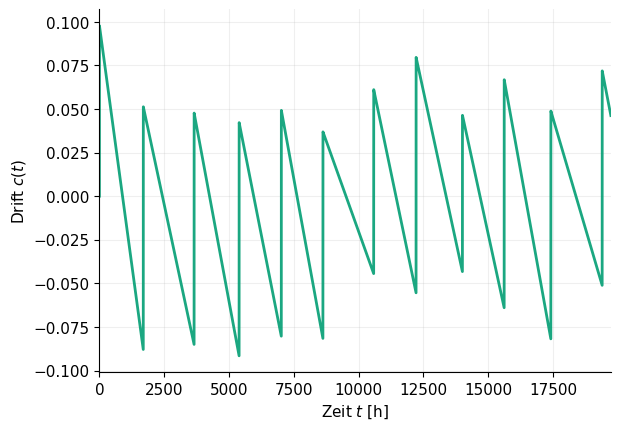

In [134]:
import matplotlib.pyplot as plt
from src.utils import thesis_style as ts

t = np.linspace(0.0, T_TOTAL, 8001)
fig, ax = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.7)), sharex=True)
ax.plot(t, drift_sawtooth(t, amplitude=ERROR_VARIANT_AMP), **ts.line("drift_signal"))
ax.set_ylabel("Drift $c(t)$")
ax.grid(True, alpha=0.2)
ax.margins(x=0)
ax.set_xlabel("Zeit $t$ [h]")
plt.tight_layout()
# plot_store.save_figure(plt.gcf(), "cd", production_cfg, final=IS_FINAL)
plt.show()

## Wahl der Drift-Amplitude

IDV(29) wirkt als Kalibrierdrift auf den aufgezeichneten Messwert XMEAS(18) = Stripper Temp; Prozess, Regelung und Zielgröße bleiben unberührt (Belege im Kopf von `temexd_mod.c`). Der relative Kalibrierfehler beträgt `ERROR_VARIANT_AMP · drift_signal(t)`, das Signal selbst überstreicht $[-0{,}5,\ +0{,}5]$.

Zwei Schranken: nach unten muss die Verschiebung des Prädiktionsfehlers über dem Innerpunkt-Rauschen des Modells liegen, nach oben muss der Fehler als schleichende Dekalibrierung plausibel bleiben, also im Bereich weniger Kelvin.


In [135]:
T_STRIPPER_NOM = 60.2      # mittlere Strippertemperatur ueber die Betriebspunkte, °C
SENS_PER_PCT = 4.4         # Kosteneinheiten je Prozent Kalibrierfehler
NOISE_FLOOR = 3.6          # Innerpunkt-Rauschen des Modells
AMPLITUDE_CANDIDATES = (0.1, 0.15, 0.2, 0.3, 0.5)

t_grid = np.linspace(0.0, 4.0 * DRIFT_PERIOD, 40001)
drift_signal_norm = drift_sawtooth(t_grid, amplitude=1.0)
signal_peak, signal_rms = float(np.max(np.abs(drift_signal_norm))), float(np.sqrt(np.mean(drift_signal_norm ** 2)))
print(f"Driftsignal: Spitzenwert |c| = {signal_peak:.2f}, Effektivwert = {signal_rms:.2f}\n")

print(f"{'amp':>6} {'Spitze %':>9} {'Spitze K':>9} {'Eff. %':>8} "
      f"{'Verschieb.':>11} {'ueber Rauschen':>15}")
for amp in AMPLITUDE_CANDIDATES:
    peak_pct, rms_pct = amp * signal_peak * 100, amp * signal_rms * 100
    shift = rms_pct * SENS_PER_PCT
    print(f"{amp:6.2f} {peak_pct:9.1f} {peak_pct / 100 * T_STRIPPER_NOM:9.1f} {rms_pct:8.1f} "
          f"{shift:11.1f} {shift / NOISE_FLOOR:15.1f}")

chosen_peak = ERROR_VARIANT_AMP * signal_peak
DRIFT_SHIFT_REF = ERROR_VARIANT_AMP * signal_rms * 100 * SENS_PER_PCT
print(f"\nGewaehlt: ERROR_VARIANT_AMP = {ERROR_VARIANT_AMP}")
print(f"  Spitzenwert des Kalibrierfehlers {100 * chosen_peak:.1f} % = "
      f"{chosen_peak * T_STRIPPER_NOM:.1f} K")
print(f"  Effektivwert {100 * ERROR_VARIANT_AMP * signal_rms:.1f} % = "
      f"{ERROR_VARIANT_AMP * signal_rms * T_STRIPPER_NOM:.1f} K")
print(f"  erwartete Verschiebung des Praediktionsfehlers "
      f"{DRIFT_SHIFT_REF:.0f} Kosteneinheiten")


Driftsignal: Spitzenwert |c| = 0.49, Effektivwert = 0.23

   amp  Spitze %  Spitze K   Eff. %  Verschieb.  ueber Rauschen
  0.10       4.9       2.9      2.3        10.1             2.8
  0.15       7.3       4.4      3.4        15.1             4.2
  0.20       9.8       5.9      4.6        20.2             5.6
  0.30      14.7       8.8      6.9        30.3             8.4
  0.50      24.5      14.7     11.5        50.5            14.0

Gewaehlt: ERROR_VARIANT_AMP = 0.2
  Spitzenwert des Kalibrierfehlers 9.8 % = 5.9 K
  Effektivwert 4.6 % = 2.8 K
  erwartete Verschiebung des Praediktionsfehlers 20 Kosteneinheiten


## Load/save error data

In [136]:
error_variant = {"idv": ERROR_VARIANT_ID, "amp": ERROR_VARIANT_AMP}
error_cfg = production_cfg.compose(error=error_variant)
ledger.bind("error", parents={"production": production_cfg.id})
print(f"error_run_id = {error_cfg.id} (Rohdaten {error_cfg.base_id})")

_error_loaded_from_cache = (data_store.exists("data_error", error_cfg)
                            and not FORCE_RECOMPUTE and not FORCE_IDV_RECOMPUTE)
_error_loaded_from_cache

error_run_id = 35ea1776 (Rohdaten 30098669)


False

In [137]:
if _error_loaded_from_cache:
    error_data = data_store.load("data_error", error_cfg, rename=True)

Simulator neu aufsetzen, damit der Fehlerfall aus definiertem Zustand startet

In [138]:
if not _error_loaded_from_cache:
    si._matlab_bridge.stop_engine()
    si = siminterface.SimInterface().setup()

In [ ]:
if not _error_loaded_from_cache:
    error_run_modes = production_data["mode"].unique().tolist()
    reset_modes = production_data.loc[production_data["reset"] == True, "mode"].to_list()
    error_data = run_simulation(si, setpoints.loc[error_run_modes], RAMP_DURATION, SOAK_TIME,
                                idv=(ERROR_VARIANT_ID, ERROR_VARIANT_AMP),
                                reset_modes=reset_modes, runtime=T_TOTAL)
    error_data["original_index"] = error_data.index
    error_data = add_reset(error_data)
    error_data.attrs = run_cfg

    data_store.save(error_data, "data_error", error_cfg)

### Gemessenes `driftf` als Spalte

Weil die Sensordrift den Prozess nicht berührt (Δy = 0), ist das Verhältnis
der aufgezeichneten Strippertemperatur punktweise **exakt** der
Kalibrierfaktor, also `x_auf = driftf · x_wahr`. Das ist ein gemessenes
Signal und braucht weder Compiler-Build noch Blockzeit noch eine
Rekonstruktion aus `DRIFT_PERIOD`. Die C-Referenz aus pytep bestätigt es bis
auf das Abtastraster (RMS 0,00X). Der nominale Lauf hat implizit
`driftf = 1`.


In [ ]:
DRIFT_SEGMENT_JUMP = 0.05
CREF_SAMPLE_STEP = 50

key = ["mode", "time"]
nominal_stripper_temp = production_data.set_index(key)["Stripper Temp"]
error_index = pd.MultiIndex.from_frame(error_data[key])
driftf = (error_data["Stripper Temp"].to_numpy()
          / nominal_stripper_temp.reindex(error_index).to_numpy())

n_unmatched = int(np.isnan(driftf).sum())
if n_unmatched:
    raise ValueError(f"{n_unmatched} Zeilen ohne Gegenstueck im nominalen Lauf -- die beiden "
                     "Laeufe muessen dieselbe Sequenz und dieselben Blockgrenzen haben.")
error_data["driftf"] = driftf

error_data["drift_segment"] = (error_data["driftf"].diff()
                               > DRIFT_SEGMENT_JUMP).cumsum().astype(int)

segments = error_data.groupby("drift_segment")["time"].agg(["min", "max", "count"])
print(f"driftf gemessen: {error_data['driftf'].min():.4f} .. "
      f"{error_data['driftf'].max():.4f}   (erwartet 1 +- {ERROR_VARIANT_AMP * 0.5:.2f})")
print(f"c = (driftf - 1) / amp: {(error_data['driftf'].min() - 1) / ERROR_VARIANT_AMP:+.4f} .. "
      f"{(error_data['driftf'].max() - 1) / ERROR_VARIANT_AMP:+.4f}")
print(f"\n{len(segments)} Driftsegmente ueber {error_data['time'].max():.0f} h "
      f"(nominell {error_data['time'].max() / DRIFT_PERIOD:.1f} Perioden a {DRIFT_PERIOD:.0f} h):")
print(segments.to_string(float_format=lambda v: f"{v:.1f}"))

c_reference = 1.0 + ERROR_VARIANT_AMP * drift_sawtooth(
    error_data["time"].to_numpy()[::CREF_SAMPLE_STEP], amplitude=1.0)
c_deviation = np.abs(error_data["driftf"].to_numpy()[::CREF_SAMPLE_STEP] - c_reference)
cref_rms = float(np.sqrt((c_deviation ** 2).mean()))
print(f"\nAbweichung der C-Referenz: max {c_deviation.max():.4f}, "
      f"RMS {cref_rms:.4f}  (nur dokumentiert, nicht verwendet)")

error_data.attrs = run_cfg
data_store.save(error_data, "data_error", error_cfg)
print("\ndata_error neu gespeichert mit den Spalten 'driftf' und 'drift_segment'.")


driftf gemessen: 0.8625 .. 1.1470   (erwartet 1 +- 0.15)
c = (driftf - 1) / amp: -0.4585 .. +0.4899

12 Driftsegmente ueber 17424 h (nominell 9.9 Perioden a 1752 h):
                  min     max  count
drift_segment                       
0                 0.0     0.0      1
1                 0.1  1693.7  33873
2              1693.7  3652.5  39177
3              3652.6  5390.1  34751
4              5390.1  7018.2  32563
5              7018.2  8623.0  32095
6              8623.0 10581.2  39165
7             10581.2 12216.0  32696
8             12216.1 14002.6  35731
9             14002.6 15613.9  32227
10            15614.0 17413.5  35993
11            17413.6 17424.0    209

Abweichung der C-Referenz: max 0.0001, RMS 0.0000  (nur dokumentiert, nicht verwendet)

data_error neu gespeichert mit den Spalten 'driftf' und 'drift_segment'.


Ausschnitt: Bloecke [297, 238, 195, 252], Variationsmass 13.98, Ablage der Segmentgrenze 0.13
Betrag der Korrelation zur Strippertemperatur: {'Purge valve': 0.49, 'Product Sep Temp': 1.0, 'Component E to Reactor': 0.46}


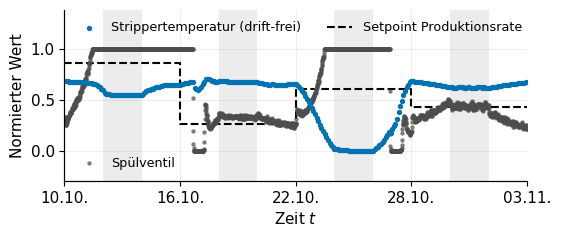

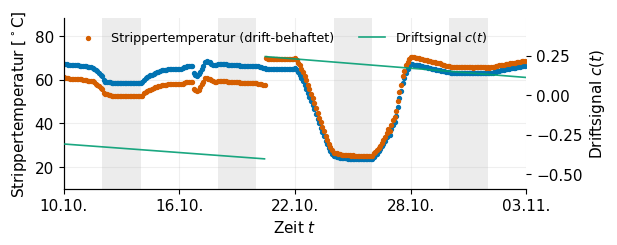

In [ ]:
import matplotlib.dates as mdates

PLOT_BLOCKS = 4
PLOT_COLUMN = "Stripper Temp"
PLOT_CONTEXT = "Purge valve"
CONTEXT_LABEL = "Spülventil"
CONTEXT_CANDIDATES = ["Purge valve", "Product Sep Temp", "Component E to Reactor"]
PLOT_SETPOINT = "ProductionSP"
STRIDE_TEMP = 40             # grob, damit die Diskretheit sichtbar bleibt
STRIDE_CONTEXT = 5           # fein, damit das Rauschen erhalten bleibt
STRIDE_DRIFT = 20            # Driftsignal ist glatt, weniger Stuetzstellen genuegen
RASTER_DPI = 300             # Punktwolken als Rasterlage im PGF
CENTER_TOL = 0.25            # zulaessige Ablage der Segmentgrenze von der Fenstermitte
HEAD_ROOM = 0.30             # Luft oben fuer die Legende, Anteil der Datenspanne
FOOT_ROOM = 0.22             # Luft unten fuer die Legende, Anteil der Datenspanne
EPOCH = pd.Timestamp("1970-01-01")
LAYOUT = dict(left=0.13, right=0.86, bottom=0.26, top=0.97)   # fuer beide Abbildungen gleich

# --- Kandidatenfenster bewerten -------------------------------------------- #
block_order = production_data["mode"].drop_duplicates().to_list()
block_times = production_data.groupby("mode", sort=False)["time"].agg(["min", "max"]).loc[block_order]

targets = setpoints.loc[block_order, original_setpoints.columns].astype(float)
target_range = (targets.max() - targets.min()).replace(0.0, 1.0)
scaled_targets = (targets - targets.min()) / target_range
step_size = scaled_targets.diff().abs().sum(axis=1).to_numpy()[1:]   # Wechsel je Blockgrenze

jumps = error_data.loc[error_data["drift_segment"].diff() > 0, "time"].to_numpy()

candidates = []
for i in range(len(block_order) - PLOT_BLOCKS + 1):
    t_start = float(block_times["min"].iloc[i])
    t_end = float(block_times["max"].iloc[i + PLOT_BLOCKS - 1])
    inside = jumps[(jumps > t_start) & (jumps < t_end)]
    if inside.size == 0:
        continue
    center = 0.5 * (t_start + t_end)
    offset = float(np.min(np.abs(inside - center)) / (0.5 * (t_end - t_start)))
    candidates.append((offset, step_size[i:i + PLOT_BLOCKS - 1].sum(), i))

centered = [c for c in candidates if c[0] <= CENTER_TOL]
offset, score, first_block = (max(centered, key=lambda c: c[1]) if centered
                              else min(candidates, key=lambda c: c[0]))
plot_blocks = block_order[first_block:first_block + PLOT_BLOCKS]
print(f"Ausschnitt: Bloecke {plot_blocks}, Variationsmass {score:.2f}, "
      f"Ablage der Segmentgrenze {offset:.2f}")

nominal_window = production_data[production_data["mode"].isin(plot_blocks)]
error_window = error_data[error_data["mode"].isin(plot_blocks)]
t_hi = float(nominal_window["time"].iloc[-1])

print("Betrag der Korrelation zur Strippertemperatur:",
      {col: round(abs(nominal_window[col].corr(nominal_window[PLOT_COLUMN])), 2)
       for col in CONTEXT_CANDIDATES})


def stamp(hours):
    """Simulationszeit als Zeitstempel ab der Unix-Epoche, analog zum synthetischen Strom.

    Liefert stets einen DatetimeIndex, auch fuer skalare Zeiten.
    """
    return EPOCH + pd.to_timedelta(np.atleast_1d(np.asarray(hours, dtype=float)), unit="h")


def unit_scale(values, reference):
    lo, hi = float(reference.min()), float(reference.max())
    return (values - lo) / (hi - lo) if hi > lo else values * 0.0


block_starts = [float(block["time"].iloc[0])
                for _, block in nominal_window.groupby("mode", sort=False)]
x_limits = (stamp(block_starts[0])[0], stamp(t_hi)[0])


def frame(ax):
    """Haltefenster hinterlegen und Achse einheitlich einstellen."""
    for _, block in nominal_window.groupby("mode", sort=False):
        t0, t_end = float(block["time"].iloc[0]), float(block["time"].iloc[-1])
        ax.axvspan(stamp(t0 + RAMP_DURATION)[0], stamp(min(t0 + SOAK_TIME, t_end))[0],
                   color=ts.C["box"], alpha=0.10, lw=0)
    ax.set_xlim(*x_limits)
    ax.set_xticks(stamp(block_starts + [t_hi]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m."))
    ax.set_xlabel("Zeit $t$")
    ax.grid(True, alpha=0.2)


def pad(ax):
    """Luft ober- und unterhalb der Daten, damit die Legende im Feld Platz findet."""
    lo, hi = ax.get_ylim()
    span = hi - lo
    ax.set_ylim(lo - FOOT_ROOM * span, hi + HEAD_ROOM * span)


temp_nom = nominal_window.iloc[::STRIDE_TEMP]
temp_err = error_window.iloc[::STRIDE_TEMP]
context_nom = nominal_window.iloc[::STRIDE_CONTEXT]

# --- (a) Betriebspunkte ----------------------------------------------------- #
fig_a, ax_a = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.38)))
frame(ax_a)

# unsichtbare zweite Ordinate, damit die Achsenbox exakt der von (b) entspricht
ax_a_mirror = ax_a.twinx()
ax_a_mirror.set_yticks([])
ax_a_mirror.set_ylabel("Driftsignal $c(t)$", color="none")
ax_a_mirror.grid(False)

edges, levels = [], []
for mode, block in nominal_window.groupby("mode", sort=False):
    edges.append(float(block["time"].iloc[0]))
    levels.append(float(setpoints.loc[mode, PLOT_SETPOINT]))
edges.append(t_hi)
levels.append(levels[-1])

ax_a.step(stamp(edges), unit_scale(np.array(levels), production_data[PLOT_SETPOINT]),
          where="post", linewidth=1.5, label="Setpoint Produktionsrate",
          **ts.line("setpoint"))
ax_a.scatter(stamp(context_nom["time"]),
             unit_scale(context_nom[PLOT_CONTEXT], production_data[PLOT_CONTEXT]),
             color=ts.C["box"], alpha=0.6, s=5, marker="o", zorder=2, label=CONTEXT_LABEL,
             rasterized=True)
ax_a.scatter(stamp(temp_nom["time"]),
             unit_scale(temp_nom[PLOT_COLUMN], production_data[PLOT_COLUMN]),
             zorder=3, label="Strippertemperatur (drift-frei)", rasterized=True,
             **ts.scatter("drift_free", s=8))
ax_a.set_ylabel("Normierter Wert")
pad(ax_a)

handles, labels = ax_a.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
top_labels = ["Strippertemperatur (drift-frei)", "Setpoint Produktionsrate"]
foot_labels = [CONTEXT_LABEL]
ax_a.add_artist(ax_a.legend([by_label[l] for l in top_labels], top_labels,
                            loc="upper left", ncol=2, frameon=False, fontsize="small"))
ax_a.legend([by_label[l] for l in foot_labels], foot_labels,
            loc="lower left", ncol=1, frameon=False, fontsize="small")
fig_a.subplots_adjust(**LAYOUT)
plot_store.save_figure(fig_a, "stream_point", error_cfg, final=IS_FINAL,
                       savefig_kwargs={"bbox_inches": None, "dpi": RASTER_DPI},
                       archive_kwargs={"bbox_inches": None, "dpi": RASTER_DPI})
plt.show()

# --- (b) Drift -------------------------------------------------------------- #
fig_b, ax_b = plt.subplots(figsize=(ts.fig_width(), ts.fig_width(0.38)))
frame(ax_b)
ax_drift = ax_b.twinx()

ax_b.scatter(stamp(temp_nom["time"]), temp_nom[PLOT_COLUMN],
             zorder=2, label="_nolegend_", rasterized=True, **ts.scatter("drift_free", s=8))
ax_b.scatter(stamp(temp_err["time"]), temp_err[PLOT_COLUMN],
             zorder=2, label="Strippertemperatur (drift-behaftet)", rasterized=True,
             **ts.scatter("drift_afflicted", s=8))
ax_b.set_ylabel(r"Strippertemperatur $[^\circ$C$]$")

drift_sample = error_window.iloc[::STRIDE_DRIFT]
c_signal = ((drift_sample["driftf"] - 1.0) / ERROR_VARIANT_AMP).to_numpy()
t_signal = stamp(drift_sample["time"])
cut = np.flatnonzero(np.diff(c_signal) > 0) + 1           # Ruecksprung nicht durchzeichnen
for a, b in zip(np.r_[0, cut], np.r_[cut, len(c_signal)]):
    ax_drift.plot(t_signal[a:b], c_signal[a:b], zorder=4,
                  label="Driftsignal $c(t)$" if a == 0 else "_nolegend_",
                  **ts.line("drift_signal", linewidth=1.2))
ax_drift.set_ylabel("Driftsignal $c(t)$")
ax_drift.set_xlim(*x_limits)
ax_drift.grid(False)
ax_drift.set_zorder(ax_b.get_zorder() + 1)               # Driftsignal im Vordergrund
ax_drift.patch.set_visible(False)

pad(ax_b)
pad(ax_drift)

handles, labels = ax_b.get_legend_handles_labels()
handles2, labels2 = ax_drift.get_legend_handles_labels()
ax_b.legend(handles + handles2, labels + labels2,
            loc="upper left", ncol=2, frameon=False, fontsize="small")
fig_b.subplots_adjust(**LAYOUT)
plot_store.save_figure(fig_b, "stream_drift", error_cfg, final=IS_FINAL,
                       savefig_kwargs={"bbox_inches": None, "dpi": RASTER_DPI},
                       archive_kwargs={"bbox_inches": None, "dpi": RASTER_DPI})
plt.show()

## Ergebnisexport

Kennzahlen der Synthese als JSON (`ResultDoc`) und als LaTeX-Makros (`MacroExport`) unter `results/tep_generation.*`.


In [ ]:
from src.utils import results_export as rx
from src.utils import latex_export as lx

MODE_WORDS = ["One", "Two", "Three", "Four", "Five", "Six"]

n_candidates = len(_prerun_records)
n_feasible = len(successful_modes)
run_points = int(production_data["mode"].nunique())
run_hours = float(production_data["time"].max())
points_by_mode = run_points_per_mode.reindex(range(n_modes)).fillna(0).astype(int)
driftf_min, driftf_max = float(error_data["driftf"].min()), float(error_data["driftf"].max())

drift_amplitude = {
    "idv": ERROR_VARIANT_ID, "amp": ERROR_VARIANT_AMP,
    "signal_peak": signal_peak, "signal_rms": signal_rms,
    "peak_pct": 100 * chosen_peak, "peak_k": chosen_peak * T_STRIPPER_NOM,
    "rms_pct": 100 * ERROR_VARIANT_AMP * signal_rms,
    "rms_k": ERROR_VARIANT_AMP * signal_rms * T_STRIPPER_NOM,
    "expected_shift": DRIFT_SHIFT_REF,
    "shift_over_noise": DRIFT_SHIFT_REF / NOISE_FLOOR,
}

(rx.ResultDoc()
   .integer("n_modes", n_modes)
   .integer("n_points_per_mode", points_per_mode)
   .integer("n_candidates", n_candidates)
   .set("magnitude_range", [MAGNITUDE_LO, MAGNITUDE_HI])
   .set("block_hours", {"ramp": RAMP_DURATION, "soak": SOAK_TIME})
   .integer("n_feasible", n_feasible)
   .num("feasible_share", n_feasible / n_candidates, 3)
   .stats(yield_by_mode, [("fahrbar", "feasible", "int"),
                          ("geprueft", "tested", "int"),
                          ("Ausbeute", "share", "num")], into="yield_per_mode")
   .integer("campaign_points", int(campaign_data["mode"].nunique()))
   .integer("campaign_rows", len(campaign_data))
   .integer("run_points", run_points)
   .integer("run_rows", len(production_data))
   .num("run_hours", run_hours, 1)
   .num("run_years", run_hours / 8760.0, 3)
   .set("run_points_per_mode", points_by_mode.to_dict())
   .set("dropped_in_sequence", dropped_in_sequence)
   .integer("n_resets", n_resets)
   .integer("n_aborts", len(stopped_in_production))
   .num("reserve_min", float(reserves.min()), 3)
   .set("drift_amplitude", drift_amplitude)
   .set("driftf", {"min": driftf_min, "max": driftf_max,
                   "c_min": (driftf_min - 1) / ERROR_VARIANT_AMP,
                   "c_max": (driftf_max - 1) / ERROR_VARIANT_AMP,
                   "n_segments": len(segments),
                   "n_periods": run_hours / DRIFT_PERIOD,
                   "cref_rms": cref_rms})
   .save(res_store, "generation", error_cfg, final=IS_FINAL,
         parents={"campaign": base_cfg.id, "production": run_id}))


mx = lx.MacroExport("Automatisch erzeugt aus tep_generation.ipynb - nicht manuell editieren")

mx.comment("Parameter (Hash-relevant, Versuchsplan)")
mx.integer("paramModes", n_modes)
mx.integer("paramPointsPerMode", points_per_mode)
mx.integer("paramCandidates", n_candidates)
mx.param("paramSetpointSpan", 100 * MAGNITUDE_HI, nd=0, unit=r"\percent")
mx.param("paramRampH", RAMP_DURATION, unit=r"\hour")
mx.param("paramSoakH", SOAK_TIME, unit=r"\hour")
mx.param("paramBlockH", RAMP_DURATION + SOAK_TIME, unit=r"\hour")
mx.integer("paramDriftIDV", ERROR_VARIANT_ID)
mx.param("paramDriftAmp", ERROR_VARIANT_AMP)
mx.param("paramDriftPeriod", DRIFT_PERIOD, unit=r"\hour")

mx.comment("Umfang der Datensaetze")
mx.integer("genFeasible", n_feasible)
mx.num("genFeasibleShare", 100 * n_feasible / n_candidates, 0, unit=r"\percent")
mx.integer("genCampaignPoints", int(campaign_data["mode"].nunique()))
mx.integer("genCampaignRows", len(campaign_data))
mx.integer("genRunPoints", run_points)
mx.integer("genRunRows", len(production_data))
mx.num("genRunHours", run_hours, 0, unit=r"\hour")
mx.num("genRunYears", run_hours / 8760.0, 2)
mx.integer("genDropped", len(dropped_in_sequence))
mx.integer("genResets", n_resets)
mx.integer("genAborts", len(stopped_in_production))
mx.integer("genMinPointsPerMode", int(points_by_mode.min()))

mx.comment("Ausbeute und Belegung je Betriebsmodus")
for mode, word in enumerate(MODE_WORDS):
    mx.integer(f"genFeasibleMode{word}", int(yield_by_mode.loc[mode, "fahrbar"]))
    mx.num(f"genYieldMode{word}", 100 * float(yield_by_mode.loc[mode, "Ausbeute"]), 0,
           unit=r"\percent")
    mx.integer(f"genPointsMode{word}", int(points_by_mode[mode]))

mx.comment("Kalibrierung der Fehleramplitude")
mx.num("genSignalPeak", signal_peak, 2)
mx.num("genSignalRms", signal_rms, 2)
mx.num("genCalPeakPct", drift_amplitude["peak_pct"], 1, unit=r"\percent")
mx.num("genCalPeakK", drift_amplitude["peak_k"], 1, unit=r"\kelvin")
mx.num("genCalRmsPct", drift_amplitude["rms_pct"], 1, unit=r"\percent")
mx.num("genCalRmsK", drift_amplitude["rms_k"], 1, unit=r"\kelvin")
mx.num("genExpectedShift", DRIFT_SHIFT_REF, 0)
mx.num("genShiftOverNoise", DRIFT_SHIFT_REF / NOISE_FLOOR, 1)

mx.comment("Absicherung")
mx.num("genMinReserve", float(reserves.min()), 2)

mx.save(res_store, "generation", error_cfg, final=IS_FINAL)


Umfassende Ergebnisse -> C:\git\process_optimization_concept_drift\results\tep_generation.json
LaTeX-Makros -> C:\git\process_optimization_concept_drift\results\tep_generation.tex

% Automatisch erzeugt aus tep_generation.ipynb - nicht manuell editieren

% Parameter (Hash-relevant, Versuchsplan)
\newcommand{\paramModes}{6}
\newcommand{\paramPointsPerMode}{50}
\newcommand{\paramCandidates}{300}
\newcommand{\paramSetpointSpan}{\SI{15}{\percent}}
\newcommand{\paramRampH}{\SI{48}{\hour}}
\newcommand{\paramSoakH}{\SI{96}{\hour}}
\newcommand{\paramBlockH}{\SI{144}{\hour}}
\newcommand{\paramDriftIDV}{29}
\newcommand{\paramDriftAmp}{\tfrac{3}{10}}
\newcommand{\paramDriftPeriod}{\SI{1752}{\hour}}

% Umfang der Datensaetze
\newcommand{\genFeasible}{137}
\newcommand{\genFeasibleShare}{\SI{46}{\percent}}
\newcommand{\genCampaignPoints}{137}
\newcommand{\genCampaignRows}{263177}
\newcommand{\genRunPoints}{121}
\newcommand{\genRunRows}{348481}
\newcommand{\genRunHours}{\SI{17424}{\hour}}
\newcommand

'C:\\git\\process_optimization_concept_drift\\results\\tep_generation.tex'

## Lauf abgeschlossen

Zeigt die Kennungen dieses Laufs in einem Fenster mit Kopier-Button (Konsolenausgabe, falls keine GUI verfuegbar ist).

In [ ]:
from src.utils.dialogs import show_with_copy_button

show_with_copy_button(
    "Lauf abgeschlossen",
    f"Datensynthese beendet.\n"
    f"Data Run-ID: {run_id}\n"
    f"Fehlerfall (IDV {ERROR_VARIANT_ID}, amp {ERROR_VARIANT_AMP}): {error_cfg.id}",
    copy_value=run_id,
)


--- Lauf abgeschlossen ---
Datensynthese beendet.
Data Run-ID: 6fe76fde
Fehlerfall (IDV 29, amp 0.3): a568acfa

